In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.survival_curve import SurvivalCurve
from src.curves.simulator.hull_white import HullWhiteSimulator

from src.instruments.instrument_builder import InstrumentBuilder

from src.trades.interest_rate_swap import InterestRateSwap

from src.pricing.swap_pricer import SwapPricer

from src.risk.exposure.stochastic_exposure_engine import MonteCarloExposureEngine

from src.xva.cva_engine import CVAEngine
from src.xva.dva_engine import DVAEngine
from src.xva.xva_report import XVAReport

Times: 0 ---> Survival Probability: 1.0000
Times: 1 ---> Survival Probability: 0.9851
Times: 2 ---> Survival Probability: 0.9704
Times: 3 ---> Survival Probability: 0.9560
Times: 4 ---> Survival Probability: 0.9418
Times: 5 ---> Survival Probability: 0.9277
Times: 6 ---> Survival Probability: 0.9139
Times: 7 ---> Survival Probability: 0.9003
Times: 8 ---> Survival Probability: 0.8869
Times: 9 ---> Survival Probability: 0.8737
Times: 10 ---> Survival Probability: 0.8607


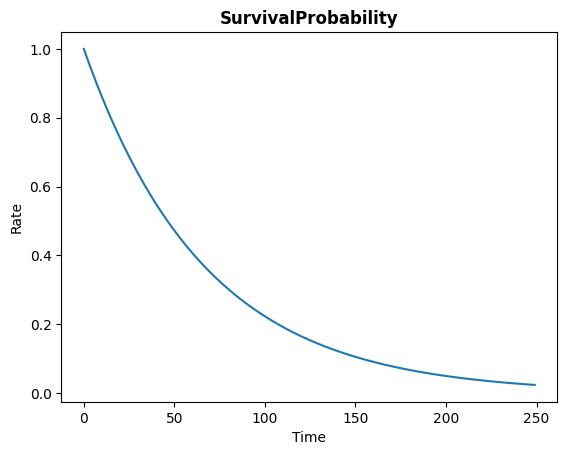

In [2]:
# survival curve
counterparty_survival_curve = SurvivalCurve(hazard_rate = 0.015)

times = list(range(250))

rows_survival = []

for t in times:
    if t <= 10: 
        print(f'Times: {t} ---> Survival Probability: {counterparty_survival_curve.survival_probability(t = t):.4f}')
    rows_survival.append({
        'Times': t, 
        'SurvivalProbability': counterparty_survival_curve.survival_probability(t = t)
    })

survival_df = pd.DataFrame(rows_survival)

plt.plot(survival_df['Times'], survival_df['SurvivalProbability'])
plt.title('SurvivalProbability', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Rate')
plt.show()


Times: 0 ---> Probability of Default: 0.0000
Times: 1 ---> Probability of Default: 0.0149
Times: 2 ---> Probability of Default: 0.0296
Times: 3 ---> Probability of Default: 0.0440
Times: 4 ---> Probability of Default: 0.0582
Times: 5 ---> Probability of Default: 0.0723
Times: 6 ---> Probability of Default: 0.0861
Times: 7 ---> Probability of Default: 0.0997
Times: 8 ---> Probability of Default: 0.1131
Times: 9 ---> Probability of Default: 0.1263
Times: 10 ---> Probability of Default: 0.1393


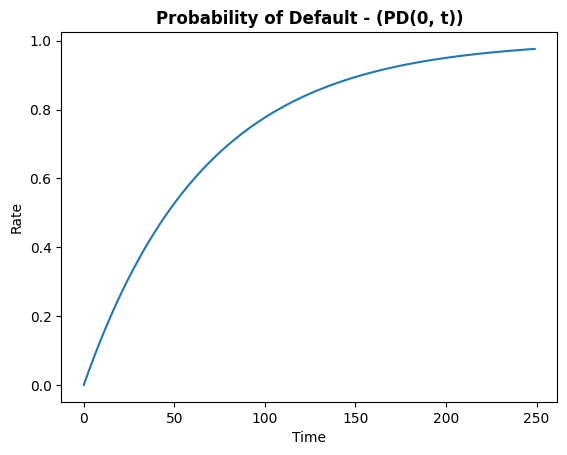

In [3]:
# probability of default - from initial point
rows_default = []

for t in times:
    if t <= 10:
        print(f'Times: {t} ---> Probability of Default: {counterparty_survival_curve.default_probability(start = times[0], end = t):.4f}')
    
    rows_default.append({
        'Times': t,
        'PD': counterparty_survival_curve.default_probability(start = times[0], end = t)
    })

default_df = pd.DataFrame(rows_default)
plt.plot(default_df['Times'], default_df['PD'])
plt.title('Probability of Default - (PD(0, t))', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Rate')
plt.show()

Times: 1 ---> Probability of Default: 0.0149
Times: 2 ---> Probability of Default: 0.0147
Times: 3 ---> Probability of Default: 0.0144
Times: 4 ---> Probability of Default: 0.0142
Times: 5 ---> Probability of Default: 0.0140
Times: 6 ---> Probability of Default: 0.0138
Times: 7 ---> Probability of Default: 0.0136
Times: 8 ---> Probability of Default: 0.0134
Times: 9 ---> Probability of Default: 0.0132
Times: 10 ---> Probability of Default: 0.0130


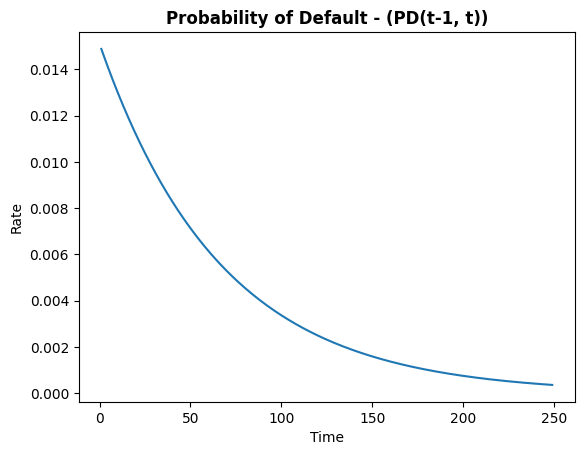

In [4]:
# probability of default - interval
rows_default = []

for t in times[1:]:
    if t <= 10:
        print(f'Times: {t} ---> Probability of Default: {counterparty_survival_curve.default_probability(start = t-1, end = t):.4f}')
    
    rows_default.append({
        'Times': t,
        'PD': counterparty_survival_curve.default_probability(start = t-1, end = t)
    })

default_df = pd.DataFrame(rows_default)
plt.plot(default_df['Times'], default_df['PD'])
plt.title('Probability of Default - (PD(t-1, t))', fontweight = 'bold')
plt.xlabel('Time')
plt.ylabel('Rate')
plt.show()

In [5]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [6]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [7]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [8]:
# sample IRS trade objects
IR_swap = InterestRateSwap(
    notional = 1_000_000,
    maturity = 3.0,
    fixed_rate = 3.40,
    pay_fixed = True
)

In [9]:
### exposure risk analytics
# pricer
pricer = SwapPricer(
    discount_curve = discount_curve,
    projection_curve = projection_curve
)

# simulator
simulator = HullWhiteSimulator(
    r0 = min(zero_curve.zero_rates.values()),
    random_seed = 12,
    mean_reversion = 0.1,
    volatility = 0.002
)

# exposure engine
mc_engine = MonteCarloExposureEngine(
    pricer = pricer,
    simulator = simulator,
    zero_curve = zero_curve
)

In [10]:
# CVA framework
cva_engine = CVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    survival_curve = counterparty_survival_curve,
    recovery_rate = 0.4
)

cva_profile, cva = cva_engine.cva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
) 

print(f'Total CVA: {cva:.1f}')

cva_profile

Total CVA: 83.9


,Times,EE,DF,PD,CVA_Contribution
0,0.00,7858.414276,0.999999,0.000000,0.000000
1,0.25,7490.225219,0.991079,0.003743,16.671380
2,0.50,7098.089779,0.982141,0.003729,15.597513
3,0.75,5718.773644,0.972673,0.003715,12.398845
4,1.00,4558.018079,0.963206,0.003701,9.749395
5,1.25,4082.127955,0.954487,0.003687,8.620071
6,1.50,3335.136975,0.945769,0.003673,6.952232
7,1.75,2489.983124,0.937051,0.003660,5.123378
8,2.00,1652.971341,0.928333,0.003646,3.356891
9,2.25,1298.426304,0.920364,0.003632,2.604454


In [11]:
# DVA framework
own_survival_curve = SurvivalCurve(hazard_rate = 0.01)

dva_engine = DVAEngine(
    exposure_engine = mc_engine,
    discount_curve = discount_curve,
    survival_curve = own_survival_curve,
    recovery_rate = 0.4
)

dva_profile, dva = dva_engine.dva_profile(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

print(f'Total DVA: {dva:.1f}')

dva_profile

Total DVA: 3.3


,Times,ENE,DF,PD,DVA_Contribution
0,0.00,-0.000000,0.999999,0.000000,-0.000000
1,0.25,-0.000000,0.991079,0.002497,-0.000000
2,0.50,24.376613,0.982141,0.002491,0.035778
3,0.75,84.633602,0.972673,0.002484,0.122712
4,1.00,179.598257,0.963206,0.002478,0.257225
5,1.25,201.544829,0.954487,0.002472,0.285330
6,1.50,289.259128,0.945769,0.002466,0.404755
7,1.75,331.594707,0.937051,0.002460,0.458569
8,2.00,488.628035,0.928333,0.002454,0.667775
9,2.25,395.334351,0.920364,0.002447,0.534302


In [12]:
# XVA reports
xva_engine = XVAReport(
    cva_engine = cva_engine,
    dva_engine = dva_engine
)

summary_report_xva = xva_engine.summary_report(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

full_report_xva = xva_engine.full_report(
    swap = IR_swap,
    n_paths = 250,
    steps_per_year = 4
)

display(summary_report_xva)
display(full_report_xva)

,Metrics,Value
0,CVA,85.659106
1,DVA,3.838654
2,BVA,-81.820452


,Times,CVA_Contribution,DVA_Contribution,BVA_Contribution
0,0.00,0.000000,-0.000000,-0.000000
1,0.25,16.473552,0.002998,-16.470554
2,0.50,15.024090,0.059539,-14.964551
3,0.75,11.971386,0.163766,-11.807619
4,1.00,9.641314,0.318107,-9.323207
5,1.25,8.050604,0.462227,-7.588378
6,1.50,7.010651,0.510813,-6.499837
7,1.75,5.296586,0.618278,-4.678308
8,2.00,3.515713,0.748655,-2.767058
9,2.25,2.834166,0.569477,-2.264690
